## Setup

In [4]:
# This cell ensures all required packages are available.
# Run it once before starting the exercise.

# If you get "ModuleNotFoundError" for any library, remove the "#" in front of the corresponding line below and run the cell again.
# !pip install numpy pandas matplotlib seaborn scikit-learn
# !pip install shap ipywidgets
# !pip install aif360

# General imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
import shap

# AIF360 imports
from aif360.datasets import BinaryLabelDataset
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.algorithms.preprocessing import Reweighing
from aif360.algorithms.postprocessing import RejectOptionClassification
from aif360.algorithms.inprocessing import PrejudiceRemover

# Set random seed for reproducibility
RANDOM_STATE = 13
np.random.seed(RANDOM_STATE)
RNG = np.random.default_rng(RANDOM_STATE) 

## Simulate a biased dataset

In [5]:
n_samples=15000
np.random.seed(RANDOM_STATE)

# Feature: sex (0=women, 1=men) - representativity bias: 1 women for every 4 men
sex = np.random.choice([0,1], size=n_samples, p=[0.2,0.8])

# Feature: education_level (1=HS, 2=Bachelor, 3=Master, 4=PhD) - education bias: woman have slightly less often a master or phd
p_edu_female = [0.3, 0.4, 0.25, 0.05]    # fewer at top levels
p_edu_male   = [0.2, 0.4, 0.3, 0.1]      # slightly more higher-educated
# --> encoded ordinal feature 
education_level = np.array([
    RNG.choice([1, 2, 3, 4], p=p_edu_male if s == 1 else p_edu_female)
    for s in sex
])

# Feature: experience_years (0-40 years)
experience_years = np.random.randint(0, 41, n_samples)

# Feature: skill (scale of 0-20; influenced most by experience, then by the education, and some variation)
skill = (
    0.6 * (experience_years / 2) +   # experience dominates
    2.0 * education_level +          # education adds a boost
    RNG.normal(0, 2, n_samples)      # noise
)
# --> put on a scale of 0-20
skill = np.clip(skill, 0, 20).round().astype(int)

# Feature: expected_salary (per year in k$) - social bias: women ask 6k$ less on average
# --> Create the salary from a normal distribution
#     (approximated from the assumption that people with a higher skill score ask for a higher salary)
expected_salary = np.random.normal(50 + 2*skill, 10, size=n_samples)
# --> Introduce bias and reduce womens expected salary by the average of 6k$
expected_salary = np.where(sex==0, expected_salary - 6, expected_salary)

# Feature: interview_score (scale of 0–10; assumption: applicants with a higher skill perform better in an interview)
interview_score = np.random.normal(
    loc=(skill / 20) * 10 + RNG.normal(0, 1, n_samples),
    scale=1
).clip(0, 10).round()

# Normalize features to 0-1
skill_n = (skill - skill.min()) / (skill.max() - skill.min())
exp_n = (experience_years - experience_years.min()) / (experience_years.max() - experience_years.min())
salary_n = (expected_salary - expected_salary.min()) / (expected_salary.max() - expected_salary.min())
interview_n = (interview_score - interview_score.min()) / (interview_score.max() - interview_score.min())

# Coefficients (weights)
β0 = 0.6   # skill
β1 = 0.15  # expected_salary
β2 = 0.1   # experience
β3 = 0.2   # interview
β4 = 0.2   # sex
βe = np.random.normal(0, 0.05, n_samples)

# Recruitment rule (biased) = β0 * skill + β1 * expected_salary + β2 * experience_years/10 + β3 * interview_score + β4 * sex + βe
recruitment_score = (
    β0 * skill_n
    - β1 * salary_n
    + β2 * exp_n
    + β3 * interview_n
    + β4 * sex
    + βe
)

# 70th percentile -> top 30% recruited
threshold = np.percentile(recruitment_score, 70)
recruited = (recruitment_score > threshold).astype(int)

print("Fraction recruited:", recruited.mean())
print("Number recruited:", recruited.sum())
print("")

# Dataset: save all features and the result from the model (recruited vs declined) in a dataframe
df = pd.DataFrame({
    "skill": skill,
    "expected_salary": expected_salary,
    "experience_years": experience_years,
    "education_level": education_level,
    "interview_score": interview_score,
    "sex": sex,
    "recruited": recruited
})

# Split the dataset into a train (80%) and a test set (20%)
df_train, df_test = train_test_split(df, test_size=0.2, random_state=RANDOM_STATE)

# Insepct the data
applicant_no = 999
print(f"Values of applicant {applicant_no}: skill={df['skill'][applicant_no]}, expected_salary={df['expected_salary'][applicant_no]}, experience_years={df['experience_years'][applicant_no]}, education_level={df['education_level'][applicant_no]}, interview_score={df['interview_score'][applicant_no]}, sex={df['sex'][applicant_no]}, recruitment_score={recruitment_score[applicant_no]}, recruited={df['recruited'][applicant_no]}")
print("")
df_train.info()
df_train.head(10)

Fraction recruited: 0.3
Number recruited: 4500

Values of applicant 999: skill=5, expected_salary=62.216441433510674, experience_years=4, education_level=2, interview_score=1.0, sex=1, recruitment_score=0.3096603158464573, recruited=0

<class 'pandas.core.frame.DataFrame'>
Index: 12000 entries, 8443 to 338
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   skill             12000 non-null  int64  
 1   expected_salary   12000 non-null  float64
 2   experience_years  12000 non-null  int64  
 3   education_level   12000 non-null  int64  
 4   interview_score   12000 non-null  float64
 5   sex               12000 non-null  int64  
 6   recruited         12000 non-null  int64  
dtypes: float64(2), int64(5)
memory usage: 750.0 KB


,skill,expected_salary,experience_years,education_level,interview_score,sex,recruited
8443,5,50.818464,10,1,1.0,0,0
10579,13,68.220464,18,3,7.0,1,1
1595,17,88.805057,35,3,8.0,0,1
9171,15,76.008608,35,2,6.0,1,1
6046,4,64.450406,0,2,3.0,1,0
4115,8,72.707509,17,3,6.0,1,0
12529,14,70.321394,16,4,9.0,1,1
5399,4,60.226120,17,1,3.0,0,0
8642,9,75.216858,0,3,3.0,1,0
14342,15,78.553657,31,2,9.0,1,1


## Visualise bias in the dataset

### Visualize the dataset itself

By visulaizing a dataset in a meaningful way (so that relevant features are visible and comparable) we can already learn a lot about the bias in the dataset.

**Task B0:**

What do you observe about the distribution of "sex" and "expected_salary"? How might this lead to bias?

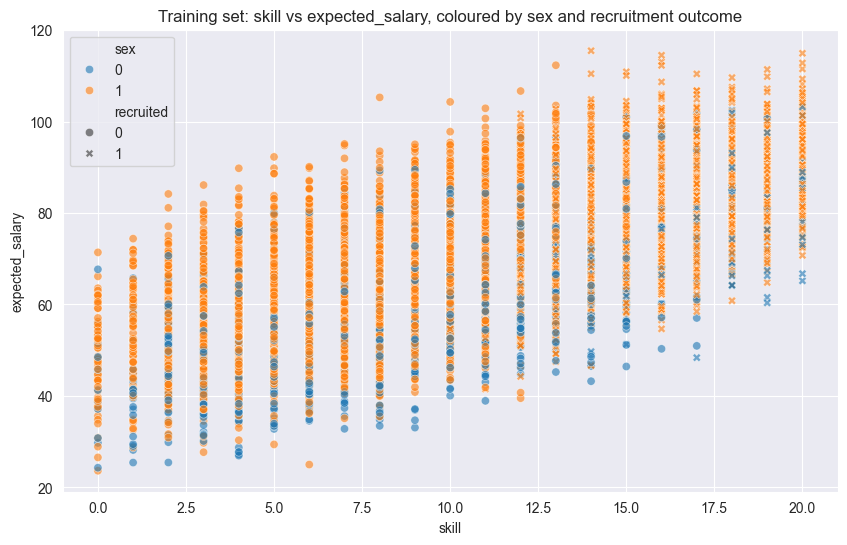

In [6]:
# Use matplotlib (plt) to create a (initally empty) figure
plt.figure(figsize=(10,6))

# Use seaborn (sns) to define a scatterplot of the data
sns.scatterplot(data=df_train, x='skill', y='expected_salary', hue='sex', style='recruited', alpha=0.6)

# Set a disciptive title for your plot
plt.title("Training set: skill vs expected_salary, coloured by sex and recruitment outcome")

# Display the figure
plt.show()

### Compute Disparate Impact of historical recruitment

To make bias in data visible, we can also use measures.

The Disparate Impact (DI) is a ratio that measures how a "protected or unprivileged group" is affected compared to a "privileged group".

**Task B1.1:**

Research the DI, how to calculate and interpret it.


In [10]:
# Get the averaged recruitment rates
rate_priv = df.loc[df.sex == 1, 'recruited'].mean()
rate_unpriv = df.loc[df.sex == 0, 'recruited'].mean()

print(f"mean priv {rate_priv} mean unpriv {rate_unpriv}")

# Calculate the DI
DI = rate_unpriv/(rate_priv)

print(f"DI (DataFrame): {DI}")
print("Women are hired with 19% of the rate of men < 80% and would not pass the US ruling ")

mean priv0.3569710541594095 mean unpriv 0.06659870880054367
DI (DataFrame): 0.18656613197215496
Women are hired with 19% of the rate of men < 80% and would not pass the US ruling 


## What to do against bias?

The AIF360 BinaryLabelDataset is a datastructure for fairness computations.

While it contains the same underlying data (features, labels, etc.) as the normal DataFrame, it adds metadata like:
- Which columns are protected attributes (e.g., sex, race)
- Which groups are privileged vs. unprivileged

In [12]:
# Wrap into BinaryLabelDataset (BLD) from AIF360

dt_train = BinaryLabelDataset(
    df=df_train,
    label_names=["recruited"],
    protected_attribute_names=["sex"]
)

dt_test = BinaryLabelDataset(
    df=df_test,
    label_names=["recruited"],
    protected_attribute_names=["sex"]
)

# Further create AIF360 BLD-Metrics

privileged_groups = [{'sex': 1}]
unprivileged_groups = [{'sex': 0}]

metric_train = BinaryLabelDatasetMetric(
    dt_train,
    privileged_groups=privileged_groups,
    unprivileged_groups=unprivileged_groups
)

metric_test = BinaryLabelDatasetMetric(
    dt_test,
    privileged_groups=privileged_groups,
    unprivileged_groups=unprivileged_groups
)

On this new data structure, we can also compute the DI.

**Task B2:**

Does this DI varies from the DI calculated for the dataframe data?
If it does, why?

In [13]:
def compute_di(binary_dataset):
    # Get the data
    bld = binary_dataset.convert_to_dataframe()[0]
    privileged = bld[bld['sex']==1]
    unprivileged = bld[bld['sex']==0]

    # Get averaged rates
    rate_priv  = privileged['recruited'].mean()
    rate_unpriv= unprivileged['recruited'].mean()
    
    print(f"rate_priv = {rate_priv}, and rate_unpriv = {rate_unpriv}")

    # Check for possible errors of the calculation (denominator = 0)
    if rate_priv == 0:
        print("Warning: Privileged group has 0 positive outcomes — DI undefined.")
        return np.nan

    # Disparate Impact = P(y=1 | unprivileged) / P(y=1 | privileged)
    return rate_unpriv / rate_priv


print("DI (BinaryLabelDataset):", compute_di(dt_train))

rate_priv = 0.35651362835526995, and rate_unpriv = 0.06805614632071459
DI (BinaryLabelDataset): 0.19089353367691136


### Strategy 1: Baseline – do nothing

In [14]:
# Get the training and testing data from the BLDs
# --> X_... are the features (or the independent variables) and y_... are the labels (or the dependent variable)
X_train = dt_train.features
y_train = dt_train.labels.ravel()
X_test  = dt_test.features
y_test  = dt_test.labels.ravel()

# Train a model (logistic regression)
preproc = ColumnTransformer([("scaler", RobustScaler(), [0,1])], remainder='passthrough')
pipeline = Pipeline([
    ('preproc', preproc),
    ('lr', LogisticRegression(C=1e9, random_state=RANDOM_STATE))
])
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

# Get measures for the trained model
print("Accuracy (baseline):", pipeline.score(X_test, y_test))
print("DI (BLD-Metric - Train):", metric_train.disparate_impact())
print("DI (BLD-Metric - Test):", metric_test.disparate_impact())

Accuracy (baseline): 0.9466666666666667
DI (BLD-Metric - Train): 0.19089353367691136
DI (BLD-Metric - Test): 0.16948198198198197


For each strategy, we can examine the build model with XAI methods.

Specifically, we'll use SHAP to get a feeling for which features the model takes into account and to which degree.

**Task B3.1:**

To what are XAI methods like SHAP applied?

**Task B3.2:**

Interpret the SHAP plots! What can you learn from them? Where is the difference between the global and the local explanation?

Count of shap_values: 3000
Count of entries of single SHAP values: 6

--- shap_values[0]: ---
.values =
array([-0.19062064,  0.01530788, -0.04477191, -0.00036069, -0.04544713,
        0.02191396])

.base_values =
np.float64(0.24467631463125408)

.data =
array([ 8.        , 60.85099552,  7.        ,  2.        ,  4.        ,
        1.        ])


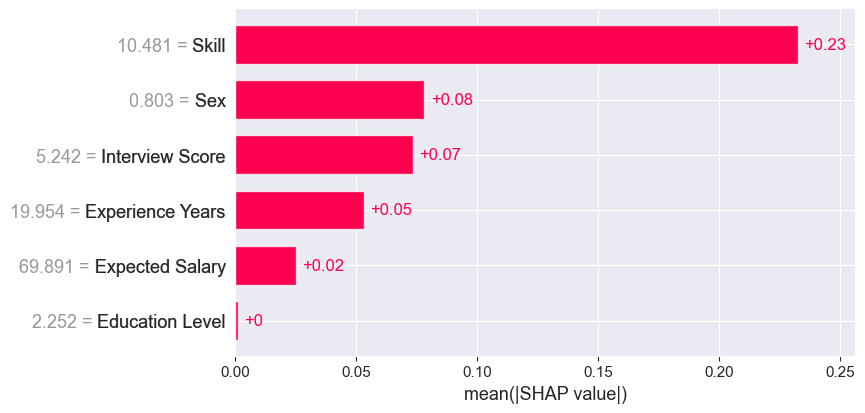

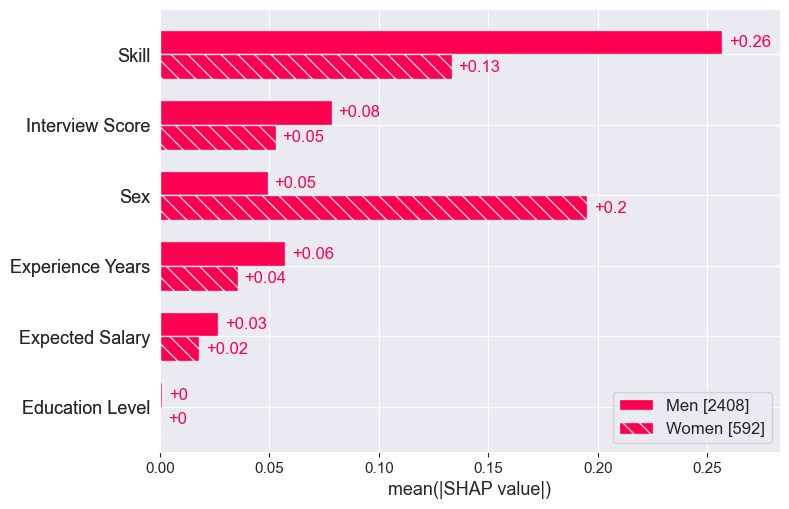

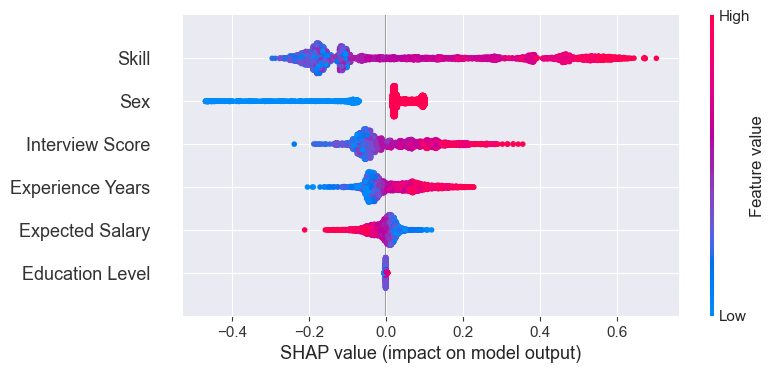

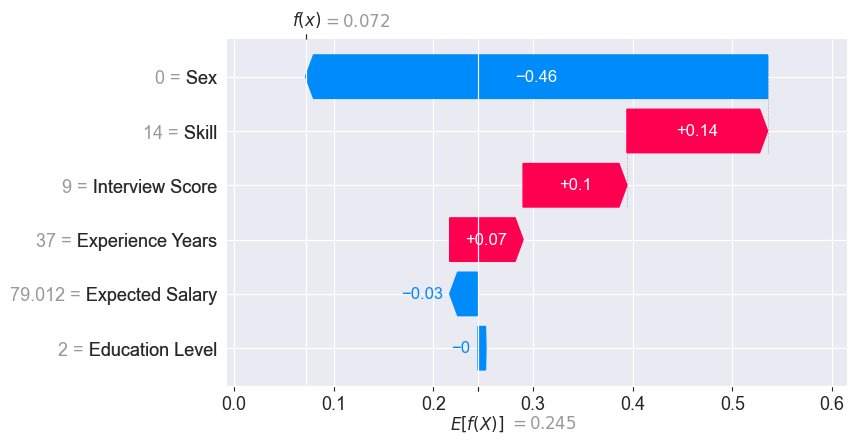

In [15]:
# Prepare data ----------------------------

FEATURES = ['Skill', 'Expected Salary', 'Experience Years', 'Education Level', 'Interview Score', 'Sex']


# Create SHAP explainer -------------------
# For more information see: https://shap.readthedocs.io/en/latest/generated/shap.Explainer.html

# Define a callable that SHAP can use
def model_predict(dataset):
    return pipeline.predict_proba(dataset)[:, 1]  # probability for class 1

# Create SHAP explainer 
explainer = shap.Explainer(model_predict, X_train, feature_names=FEATURES)

# Compute SHAP values
shap_values = explainer(X_test)

# Get familiar with the shap values
print(f"Count of shap_values: {shap_values.shape[0]}")
print(f"Count of entries of single SHAP values: {shap_values[0].shape[0]}")
print("")
print("--- shap_values[0]: ---")
print(shap_values[0])


# Global Explanation -------------------

# Bar Plot: shows the mean absolute SHAP values per feature
# --> https://shap.readthedocs.io/en/latest/example_notebooks/api_examples/plots/bar.html#Global-bar-plot
shap.plots.bar(shap_values, show_data=True, show=True)

# Cohort Bar Plot
# --> https://shap.readthedocs.io/en/latest/example_notebooks/api_examples/plots/bar.html#Cohort-bar-plot
sex = ["Women" if shap_values.data[i, -1] == 0 else "Men" for i in range(shap_values.data.shape[0])]
shap.plots.bar(shap_values.cohorts(sex).abs.mean(0))

# Summary plot (beeswarm): shows feature importance and direction of effect
# --> https://shap.readthedocs.io/en/latest/example_notebooks/api_examples/plots/beeswarm.html#A-simple-beeswarm-summary-plot
shap.plots.beeswarm(shap_values, show=True)


# Local Explanations -------------------

applicant2_no = 3

# Waterfall Plot:
# --> https://shap.readthedocs.io/en/latest/example_notebooks/api_examples/plots/waterfall.html
shap.plots.waterfall(shap_values[applicant2_no], show=True)


Additionally to SHAP, we can also use DICE to generate a feeling on how the model creates its predictions.

DICE can generate different examples based on a given instance.
Here, we can take the values of a specific applicant and use DICE to vary some of these values. This allows us to see examples of feature value combinations that lead an applicant to be recruited or rejected.

**Task B4:**

Try varying DICE's threshold and the list of varying features. Note your observations. What can you infer based on the generated examples?

In [16]:
import dice_ml

FEATURES_COMPLETE = ['skill', 'expected_salary', 'experience_years', 'education_level', 'interview_score', 'sex', 'recruited']
FEATURES_WO_RECRUITED = ['skill', 'expected_salary', 'experience_years', 'education_level', 'interview_score', 'sex']


# Prepare the DICE explainer - Note that DICE requires DataFrames to work with
dice_d = dice_ml.Data(dataframe = df_train, continuous_features = FEATURES_WO_RECRUITED, outcome_name = 'recruited')
dice_m = dice_ml.Model(model = pipeline, backend='sklearn', model_type='regressor')
dice_explainer = dice_ml.Dice(dice_d, dice_m, method='genetic')

# Define necessary variables for DICE
dice_threshold = 0.5     # <--- TODO - Task B4: Try varying the threshold (Hint: The value must lie between 0.0 and 1.0)
varying_features_list = ['skill', 'experience_years', 'interview_score', 'sex'] #  <--- TODO - Task B4: Try adjusting this list of features whose values should vary from example to example
example_no = 7           # -> Number of example instances to calculate
target_range = [0.5,1.5] # -> The range of the target parameter; here, for 'recruited' = 0 set range to [0,0.5], for 'recruited' = 1 set range to [0.5,1.5]

applicant3_no = 79
input_vals = [[df['skill'][applicant3_no], df['expected_salary'][applicant3_no], df['experience_years'][applicant3_no], df['education_level'][applicant3_no], df['interview_score'][applicant3_no], df['sex'][applicant3_no]]]

# Get the DiCE Explanation
input_values_df = pd.DataFrame(input_vals, columns=FEATURES_WO_RECRUITED)
dice_when_exp = dice_explainer.generate_counterfactuals(
    query_instances = input_values_df,
    total_CFs = example_no,
    features_to_vary  = varying_features_list,
    stopping_threshold = dice_threshold,
    desired_range = target_range
)

# Init feature value matrix with schema:
# [ ['feature1 name', cf1_val, cf2_val, ...], ['feature2 name', cf1_val, cf2_val, ...], ...]
feature_value_matrix = []

# Copy the example values to the matirx
cfs_as_df = dice_when_exp.cf_examples_list[0].final_cfs_df
for feature in FEATURES_COMPLETE:
    feature_of_cfs_value_list = [feature]
    for i in range (example_no):
        feature_of_cfs_value_list.append(cfs_as_df[feature].values[i])
    #feature_of_cfs_value_list.append(df[feature][applicant3_no])
    feature_value_matrix.append(feature_of_cfs_value_list)


# Create DataFrame from matrix (Feature + CF values)
cf_labels = [f'Example_{i+1}' for i in range(example_no)]
cf_table = pd.DataFrame(feature_value_matrix, columns=['Feature'] + cf_labels)

# Now insert factual (original) values as a new column
factual_values = [df.loc[applicant3_no, feature] for feature in FEATURES_COMPLETE]
cf_table.insert(1, f'Original applicant {applicant3_no}', factual_values)

# Display the generated examples
cf_table

  0%|          | 0/1 [00:00<?, ?it/s]/Users/jan.vaorin/PycharmProjects/JupyterProject1/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RobustScaler was fitted without feature names
  warnings.warn(
/Users/jan.vaorin/PycharmProjects/JupyterProject1/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RobustScaler was fitted without feature names
  warnings.warn(
/Users/jan.vaorin/PycharmProjects/JupyterProject1/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RobustScaler was fitted without feature names
  warnings.warn(
/Users/jan.vaorin/PycharmProjects/JupyterProject1/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RobustScaler was fitted without feature names
  warnings.warn(
/Users/jan.vaorin/PycharmProjects/JupyterProject1/.venv/lib/python3.13/site-package

,Feature,Original applicant 79,Example_1,Example_2,Example_3,Example_4,Example_5,Example_6,Example_7
0,skill,6.000000,17.0000,16.0000,14.0000,15.0000,19.0000,19.0000,14.0000
1,expected_salary,89.817297,89.8173,89.8173,89.8173,89.8173,89.8173,89.8173,89.8173
2,experience_years,9.000000,26.0000,34.0000,38.0000,37.0000,4.0000,3.0000,19.0000
3,education_level,1.000000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
4,interview_score,2.000000,2.6000,1.2000,3.3000,3.5000,4.1000,4.2000,6.0000
5,sex,1.000000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
6,recruited,0.000000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


To get a final impression on the model's decision making, we can generate rules with Anchors.

Anchors takes a specific instance and calculates rules that, if followed, lead to the same outcome/prediction than the given instance's (with a specified probability).


**Task B5.1:**

Try varying Anchors' threshold and note your observations. What does the threshold represent here?


**Task B5.2:**

Describe the Anchors explanation in such detail that someone without any prior knowledge can understand it.

In [17]:
from anchor import anchor_tabular

# Prepare data for ANCHOR
X_df = df_train.drop('recruited', axis = 1)
anchor_input_vals = np.array(input_vals[0])
anchor_threshold = 0.9

# Create an ANCHOR explainer - Note: The anchor tabular explainer needs  an np-array as input
anchor_explainer = anchor_tabular.AnchorTabularExplainer(class_names=['recruited'], feature_names=FEATURES_WO_RECRUITED, train_data=X_df.to_numpy())

# Generate an ANCHOR explanation
anchor_explanation = anchor_explainer.explain_instance(anchor_input_vals, pipeline.predict, threshold=anchor_threshold)
anchor_rules = anchor_explanation.names()

# Print the rules generated by ANCHOR
print(anchor_rules)

ImportError: cannot import name 'anchor_tabular' from 'anchor' (/Users/jan.vaorin/PycharmProjects/JupyterProject1/.venv/lib/python3.13/site-packages/anchor/__init__.py)

## Strategy 2: Pre-processing – Remove sensitive attribute

**Task B6:**

Why might removing the feature 'sex' not eliminate bias?

In [19]:
# Implement model without sex attribute
# --> Find index of 'sex' column
sex_idx = dt_train.feature_names.index('sex')
# --> Get all feature indices wihtout the one for sex
feature_idx_ns = [i for i in range(dt_train.features.shape[1]) if i != sex_idx]
# --> Drop the 'sex' columns from the training and testing sets
X_train_ns = dt_train.features[:, feature_idx_ns]
X_test_ns  = dt_test.features[:, feature_idx_ns]
# --> Labels remain the same
y_train = dt_train.labels.ravel()
y_test  = dt_test.labels.ravel()

# Build a logical regression model
pipeline_ns = Pipeline([
    ('preproc', RobustScaler()),
    ('lr', LogisticRegression(C=1e9, random_state=RANDOM_STATE))
])
pipeline_ns.fit(X_train_ns, y_train)
y_pred_ns = pipeline_ns.predict(X_test_ns)

dt_pred_ns = dt_test.copy()
dt_pred_ns.labels = y_pred_ns.reshape(-1,1)

# Wrap into AIF360 BLD-Metric
metric_dt_pred_ns = BinaryLabelDatasetMetric(
    dt_pred_ns,
    privileged_groups=privileged_groups,
    unprivileged_groups=unprivileged_groups
)

print("Accuracy (no sex):", pipeline_ns.score(X_test_ns, y_test))
print("DI (BLD-Metric - No sex):", metric_dt_pred_ns.disparate_impact())

Accuracy (no sex): 0.903
DI (BLD-Metric - No sex): 0.7250185965782296


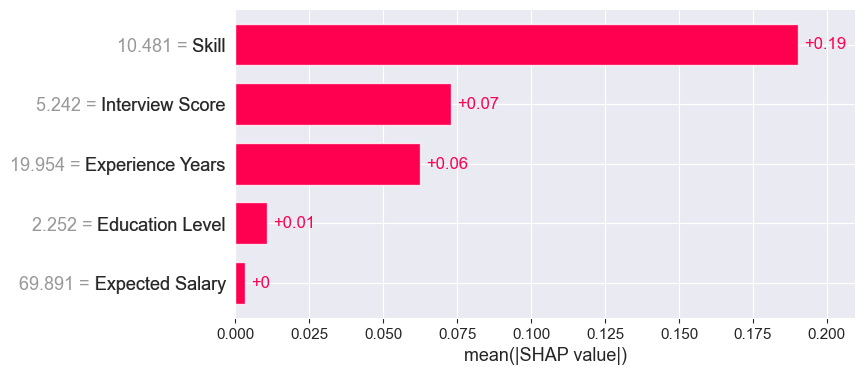

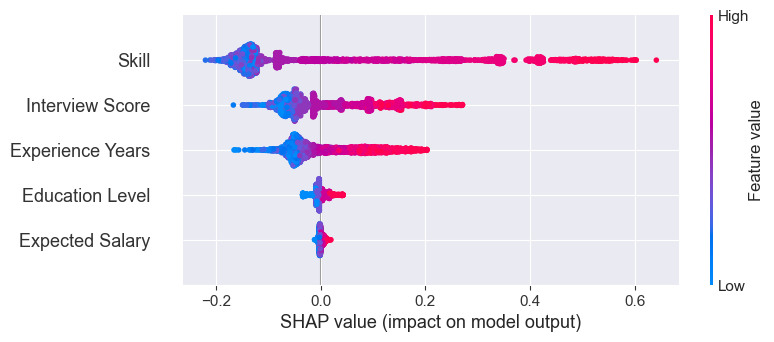

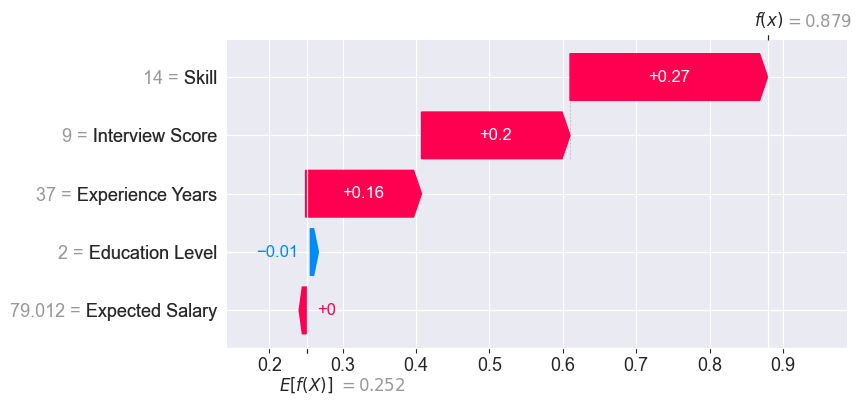

In [20]:
# Prepare data ----------------------------

FEATURES_NS = ['Skill', 'Expected Salary', 'Experience Years', 'Education Level', 'Interview Score']


# Greate SHAP explainer -------------------

# Define a callable that SHAP can use
def model_predict_ns(dataset):
    return pipeline_ns.predict_proba(dataset)[:, 1]  # probability for class 1

# Create SHAP explainer
explainer_ns = shap.Explainer(model_predict_ns, X_train_ns, feature_names=FEATURES_NS)

# Compute SHAP values
shap_values_ns = explainer_ns(X_test_ns)


# Global Explanation -------------------

# Bar Plot: shows the mean absolute SHAP values per feature
# --> https://shap.readthedocs.io/en/latest/example_notebooks/api_examples/plots/bar.html#Global-bar-plot
shap.plots.bar(shap_values_ns, show_data=True, show=True)

# Summary plot (beeswarm): shows feature importance and direction of effect
# --> https://shap.readthedocs.io/en/latest/example_notebooks/api_examples/plots/beeswarm.html#A-simple-beeswarm-summary-plot
shap.plots.beeswarm(shap_values_ns, show=True)


# Local Explanations -------------------

# Waterfall Plot:
# --> https://shap.readthedocs.io/en/latest/example_notebooks/api_examples/plots/waterfall.html
shap.plots.waterfall(shap_values_ns[applicant2_no], show=True)

## Strategy 3: Pre-processing – Reweighing

In [21]:
# Reweigh using the AIF360 reweighing preprocessing
RW = Reweighing(privileged_groups=[{'sex':1}], unprivileged_groups=[{'sex':0}])
dt_train_rw = RW.fit_transform(dt_train)
print(dt_train_rw)

# Get instance weights
weights = dt_train_rw.instance_weights

pipeline_rw = Pipeline([
    ('preproc', ColumnTransformer([("scaler", RobustScaler(), [0,1])], remainder='passthrough')),
    ('lr', LogisticRegression(C=1e9, random_state=RANDOM_STATE))
])
pipeline_rw.fit(dt_train_rw.features, dt_train_rw.labels.ravel(), lr__sample_weight=weights)
y_pred_rw = pipeline_rw.predict(X_test)

dt_pred_rw = dt_test.copy()
dt_pred_rw.labels = y_pred_rw.reshape(-1,1)

# Wrap into AIF360 BLD-Metric
metric_dt_pred_rw = BinaryLabelDatasetMetric(
    dt_pred_rw,
    privileged_groups=privileged_groups,
    unprivileged_groups=unprivileged_groups
)

print("Accuracy (reweighing):", pipeline_rw.score(X_test, y_test))
print("DI (BLD-Metric - Reweighing):", metric_dt_pred_rw.disparate_impact())

               instance weights features                                   \
                                                                            
                                   skill expected_salary experience_years   
instance names                                                              
8443                   0.751118      5.0       50.818464             10.0   
10579                  0.841483     13.0       68.220464             18.0   
1595                   4.408125     17.0       88.805057             35.0   
9171                   0.841483     15.0       76.008608             35.0   
6046                   1.087824      4.0       64.450406              0.0   
...                         ...      ...             ...              ...   
10982                  1.087824     12.0       83.099774             31.0   
7696                   1.087824      5.0       58.741882             13.0   
74                     0.841483     17.0       66.134355             38.0   

**Task B7.1:**

Visualize the training set after reweighing (plot weighted points) and explain how this changes the decision boundary.

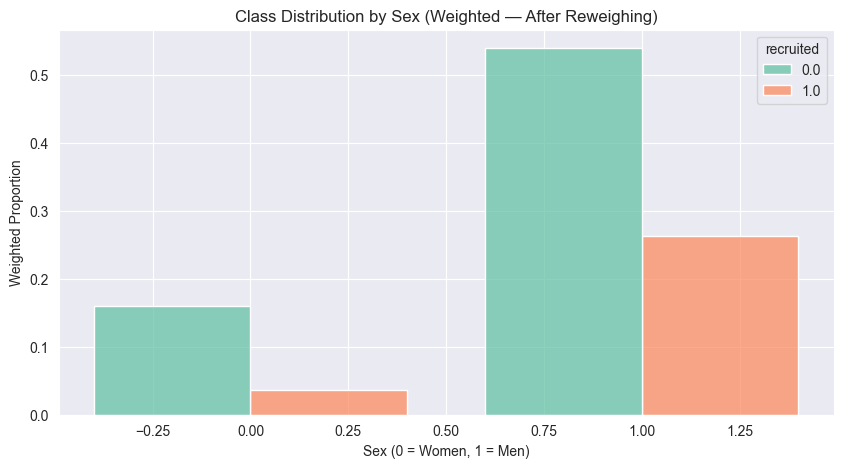

Average instance weights by sex and label:
sex  recruited
0.0  0.0          0.751
     1.0          4.408
1.0  0.0          1.088
     1.0          0.841
Name: weight, dtype: float64


In [22]:
# Extract relevant data from AIF360 datasets
# Original training data
original_training_data = pd.DataFrame(dt_train.features, columns=['skill', 'expected_salary', 'experience_years', 'education_level', 'interview_score', 'sex'])
original_training_data['recruited'] = dt_train.labels.ravel()
original_training_data['weight'] = 1.0  # baseline

# Reweighed training data
reweighed_training_data = pd.DataFrame(dt_train_rw.features, columns=['skill', 'expected_salary', 'experience_years', 'education_level', 'interview_score', 'sex'])
reweighed_training_data['recruited'] = dt_train_rw.labels.ravel()
reweighed_training_data['weight'] = dt_train_rw.instance_weights

# Combine for visualization
original_training_data['dataset'] = 'Original'
reweighed_training_data['dataset'] = 'Reweighed'
df_vis = pd.concat([original_training_data, reweighed_training_data], ignore_index=True)


# TODO - Task B7.2: Visualize weight distribution by group


# TODO - Task B7.3: Visualize group × label balance before and after reweighing

# Weighted comparison
plt.figure(figsize=(10,5))
sns.histplot(
    data=df_vis,
    x='sex',
    hue='recruited',
    multiple='dodge',
    stat='probability',
    weights='weight',
    shrink=0.8,
    palette='Set2',
    bins=2,
    discrete=True
)
plt.title("Class Distribution by Sex (Weighted — After Reweighing)")
plt.xlabel("Sex (0 = Women, 1 = Men)")
plt.ylabel("Weighted Proportion")
plt.show()


# Summary statistics
print("Average instance weights by sex and label:")
print(reweighed_training_data.groupby(['sex', 'recruited'])['weight'].mean().round(3))


**Task B8.1:**

Generate SHAP explanations for the reweighed data. Note any differences between the results from strategy 1 and 2 to this one.

In [23]:
# Greate SHAP explainer -------------------

# Define a callable that SHAP can use
def model_predict_rw(dataset):
    return pipeline_rw.predict_proba(dataset)[:, 1]  # probability for class 1

# Create SHAP explainer
# -> Note: Here we're using all features again!
explainer_rw = shap.Explainer(model_predict_rw, dt_train_rw.features, feature_names=FEATURES)

# Compute SHAP values
shap_values_rw = explainer_rw(X_test)


# TODO - Task B8.2: Generate the SHAP plots

## Strategy 4: Post-processing – Reject Option Classification

**Task B9:**

Vary ROC_margin from 0 to 0.5 in steps, record accuracy & DI, plot fairness-utility trade-off.

In [ ]:
# Note: This uses the pipeline from strategy 1
y_prob = pipeline.predict_proba(X_test)[:,1]
dt_test_pr = dt_test.copy()
dt_test_pr.scores = y_prob.reshape(-1,1)

ROC = RejectOptionClassification(privileged_groups=[{'sex':1}], unprivileged_groups=[{'sex':0}])
ROC.classification_threshold = 0.5
ROC.ROC_margin = 0.15                       # <--- TODO - Task B9: Try varying this value

# Note: y_pred_post is already an AIF360 BinaryLabelDataset!
y_pred_post = ROC.predict(dt_test_pr)

# Wrap into AIF360 BLD-Metric
metric_dt_pred_post = BinaryLabelDatasetMetric(
    y_pred_post,
    privileged_groups=privileged_groups,
    unprivileged_groups=unprivileged_groups
)

print("Accuracy (post-processing):", (y_pred_post.labels.ravel()==y_test).mean())
print("DI (BLD-Metric - post-processing):", metric_dt_pred_post.disparate_impact())

**Task B10:**

Can we meaningfully apply SHAP here?
If yes, do it in the code area below. If not, explain why!

In [ ]:
# TODO - Task B10: Apply SHAP to strategy 4 if possible

## Strategy 5: In-processing – Prejudice Remover

**Task B11:**

Vary the `eta` value (e.g., 1, 10, 100) and record the accuracy & the DI for each variation.
Interpret the results.


In [ ]:
pr = PrejudiceRemover(eta=10.0)                       # <--- TODO - Task B11: Try varying the eta value
pr.fit(dt_train)
y_pred_pr = pr.predict(dt_test).labels.ravel()

dt_pred_pr = dt_test.copy()
dt_pred_pr.labels = y_pred_pr.reshape(-1,1)

# Wrap into AIF360 BLD-Metric
metric_dt_pred_pr = BinaryLabelDatasetMetric(
    dt_pred_pr,
    privileged_groups=privileged_groups,
    unprivileged_groups=unprivileged_groups
)

print("Accuracy (prejudice-remover):", (y_pred_pr==y_test).mean())
print("DI (BLD-Metric - prejudice-remover):", metric_dt_pred_pr.disparate_impact())

In [ ]:
# Greate SHAP explainer -------------------

# Note: dt_train / dt_test have shape (12000, 6) / (3000, 6), meaining only the six features without the target 'recruited'
FEATURES_WO_RECRUITED = ['skill', 'expected_salary', 'experience_years', 'education_level', 'interview_score', 'sex']

# Define a callable that SHAP can use
def model_predict_pr(X_pr):
    if isinstance(X_pr, np.ndarray):
        X_pr = pd.DataFrame(X_pr, columns=FEATURES_WO_RECRUITED)
    tmp_data = BinaryLabelDataset(
        favorable_label=1,
        unfavorable_label=0,
        df=X_pr.assign(recruited=0),
        label_names=['recruited'],
        protected_attribute_names=['sex']
    )
    preds = pr.predict(tmp_data)
    return preds.scores

# Create SHAP explainer
explainer_pr = shap.Explainer(model_predict_pr, dt_train.features[:150], feature_names=FEATURES_WO_RECRUITED)

# Compute SHAP values
shap_values_pr = explainer_pr(dt_test.features[:150])


# Global Explanation -------------------
# For more information see: https://shap.readthedocs.io/en/latest/api.html#plots

# Bar Plot: shows the mean absolute SHAP values per feature
# --> https://shap.readthedocs.io/en/latest/example_notebooks/api_examples/plots/bar.html#Global-bar-plot
shap.plots.bar(shap_values_pr, show_data=True)

# Cohort Bar Plot
# --> https://shap.readthedocs.io/en/latest/example_notebooks/api_examples/plots/bar.html#Cohort-bar-plot
sex = ["Women" if shap_values_pr.data[i, -1] == 0 else "Men" for i in range(shap_values_pr.data.shape[0])]
shap.plots.bar(shap_values_pr.cohorts(sex).abs.mean(0))

# Summary plot (beeswarm): shows feature importance and direction of effect
# --> https://shap.readthedocs.io/en/latest/example_notebooks/api_examples/plots/beeswarm.html#A-simple-beeswarm-summary-plot
shap.plots.beeswarm(shap_values_pr, show=True)


# Local Explanations -------------------

# Waterfall Plot:
# --> https://shap.readthedocs.io/en/latest/example_notebooks/api_examples/plots/waterfall.html
shap.plots.waterfall(shap_values_pr[applicant2_no], show=True)

## Your strategy & reflection

**Task B12:**

Which strategy do you think worked best and why?

**Task B13:**

Propose a new strategy, e.g., implement a rule: `if expected_salary < threshold then hire based on skill only; else apply model`. Or drop `expected_salary` altogether.

Implement your rule & model, compute metrics, and visualize the decision boundary.

In [ ]:
#TODO - Task B13: 